# 10 — E6: Layer Dynamics and Flow Typology

**Hypothesis:** Recurring processing signatures exist and are conserved across languages.

For each concept, tracks how its circuit evolves across layers: which neurons are
recruited, persist, or are consumed at each transition. Clusters concepts into
flow types (flash, build-and-hold, two-phase, late emergence, cascade).

In [1]:
# Cell 1 – Configuration
import subprocess, sys, os
for pkg in ["h5py", "numpy", "pandas", "scipy", "matplotlib", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import numpy as np
import pandas as pd
import h5py
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_CONFIGS = {
    "QW": {"id": "Qwen/Qwen2.5-Coder-7B",                "n_layers": 28, "mlp_dim": 3584},
    "DS": {"id": "deepseek-ai/deepseek-coder-6.7b-base",  "n_layers": 32, "mlp_dim": 4096},
}
COMBOS = [
    {"lang": "P", "model": "QW", "label": "Python/Qwen"},
    {"lang": "R", "model": "QW", "label": "Rust/Qwen"},
]

EPSILON = 0.5
CONSISTENCY = 0.8
N_LAYERS = max(c["n_layers"] for c in MODEL_CONFIGS.values())

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import shutil
    mp = "/content/drive"
    subprocess.run(["fusermount", "-uz", mp], capture_output=True)
    if os.path.isdir(mp):
        shutil.rmtree(mp, ignore_errors=True)
    drive.mount(mp)
    DATA_DIR = "/content/drive/MyDrive/DATA/New-Atlas"
else:
    DATA_DIR = "/Users/piotrwilam/Data/New-Atlas"



print(f"Settings: eps={EPSILON}, cons={CONSISTENCY}")

Settings: eps=0.5, cons=0.8


In [2]:
# Cell 2 – Load universal masks

all_masks = {}  # (lang, model) -> {concept: {layer: mask}}

for combo in COMBOS:
    prefix = f"{combo['lang']}_{combo['model']}_"
    key = (combo["lang"], combo["model"])
    path = os.path.join(DATA_DIR, f"{prefix}3_object_masks_eps{EPSILON}_cons{CONSISTENCY}.h5")

    if not os.path.exists(path):
        print(f"  WARNING: missing {path}")
        continue

    masks = {}
    with h5py.File(path, "r") as f:
        if "universal_masks" in f:
            um = f["universal_masks"]
            for lid in range(N_LAYERS):
                lk = f"layer_{lid}"
                if lk not in um:
                    continue
                for ds_name in um[lk]:
                    if ds_name not in masks:
                        masks[ds_name] = {}
                    masks[ds_name][lid] = np.array(um[lk][ds_name], dtype=bool)
    all_masks[key] = masks
    print(f"  {combo['label']}: {len(masks)} concepts")

  Python/Qwen: 106 concepts
  Rust/Qwen: 75 concepts


In [3]:
# Cell 3 – Compute flow vectors

flow_data = []  # per-concept flow profiles
size_data = []  # per-concept circuit size curves

for (lang, model), masks in all_masks.items():
    for concept, layers in masks.items():
        # Circuit size curve
        sizes = []
        for lid in range(N_LAYERS):
            m = layers.get(lid)
            sizes.append(int(m.sum()) if m is not None else 0)
            size_data.append({
                "lang": lang, "model": model, "concept": concept,
                "layer": lid, "circuit_size": sizes[-1],
            })

        # Flow vectors: recruited, persistent, consumed per transition
        for lid in range(N_LAYERS - 1):
            curr = layers.get(lid)
            nxt = layers.get(lid + 1)
            if curr is None or nxt is None:
                continue

            curr_set = set(np.where(curr)[0])
            nxt_set = set(np.where(nxt)[0])

            recruited = len(nxt_set - curr_set)
            persistent = len(curr_set & nxt_set)
            consumed = len(curr_set - nxt_set)
            total = len(curr_set)

            flow_data.append({
                "lang": lang, "model": model, "concept": concept,
                "transition": f"{lid}->{lid+1}",
                "layer_from": lid,
                "recruited": recruited,
                "persistent": persistent,
                "consumed": consumed,
                "recruited_frac": recruited / total if total > 0 else 0.0,
                "persistent_frac": persistent / total if total > 0 else 0.0,
                "consumed_frac": consumed / total if total > 0 else 0.0,
            })

df_flow = pd.DataFrame(flow_data)
df_sizes = pd.DataFrame(size_data)
print(f"Flow data: {len(df_flow)} rows")
print(f"Size data: {len(df_sizes)} rows")

Flow data: 4887 rows
Size data: 5792 rows


In [4]:
# Cell 4 – Flow type classification

def classify_flow_type(sizes):
    """Classify a circuit size curve into a flow type."""
    sizes = np.array(sizes, dtype=float)
    if sizes.max() == 0:
        return "empty"

    max_size = sizes.max()
    mean_size = sizes.mean()
    peak_idx = sizes.argmax()
    n = len(sizes)

    # Threshold: where circuit is >50% of max
    above_half = sizes > 0.5 * max_size
    width = above_half.sum()

    # Flash: narrow spike
    if max_size > 5 * mean_size and width <= 3:
        return "flash"

    # Late emergence: near-zero first half, spike in second half
    first_half_max = sizes[:n//2].max()
    if first_half_max < 0.1 * max_size and peak_idx >= n//2:
        return "late_emergence"

    # Two-phase: two peaks separated by trough
    # Find local maxima
    peaks = []
    for i in range(1, n-1):
        if sizes[i] > sizes[i-1] and sizes[i] > sizes[i+1] and sizes[i] > 0.3 * max_size:
            peaks.append(i)
    if len(peaks) >= 2:
        # Check if trough between first and last peak is <50% of peaks
        trough = sizes[peaks[0]:peaks[-1]+1].min()
        if trough < 0.5 * min(sizes[peaks[0]], sizes[peaks[-1]]) and peaks[-1] - peaks[0] >= 3:
            return "two_phase"

    # Build-and-hold: gradual rise then plateau
    # Check for monotone increase over >=4 layers
    longest_increase = 0
    current_increase = 0
    for i in range(1, n):
        if sizes[i] >= sizes[i-1]:
            current_increase += 1
            longest_increase = max(longest_increase, current_increase)
        else:
            current_increase = 0
    if longest_increase >= 4 and width >= n // 3:
        return "build_and_hold"

    # Cascade: recruited fraction stays >30% for >=5 consecutive transitions
    # (checked in flow data, not here — fallback)

    return "unclassified"


# Classify each concept
flow_types = []
for (lang, model), sub in df_sizes.groupby(["lang", "model"]):
    for concept, csub in sub.groupby("concept"):
        sizes = csub.sort_values("layer")["circuit_size"].tolist()
        ft = classify_flow_type(sizes)
        flow_types.append({
            "lang": lang, "model": model, "concept": concept,
            "flow_type": ft,
            "max_size": max(sizes),
            "peak_layer": sizes.index(max(sizes)),
        })

df_flow_types = pd.DataFrame(flow_types)

print("Flow type distribution:")
for (lang, model), sub in df_flow_types.groupby(["lang", "model"]):
    print(f"\n  {lang}_{model}:")
    for ft, count in sub["flow_type"].value_counts().items():
        print(f"    {ft:20s} {count}")

Flow type distribution:

  P_QW:
    late_emergence       95
    two_phase            7
    unclassified         4

  R_QW:
    late_emergence       71
    unclassified         2
    two_phase            2


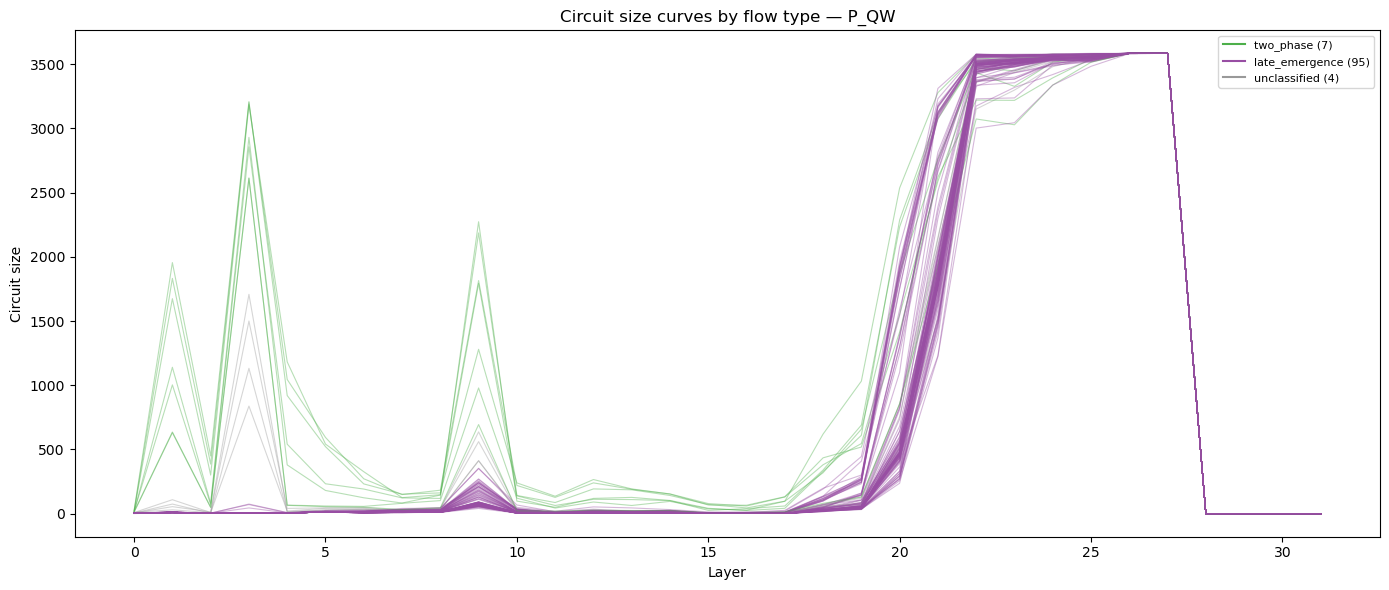

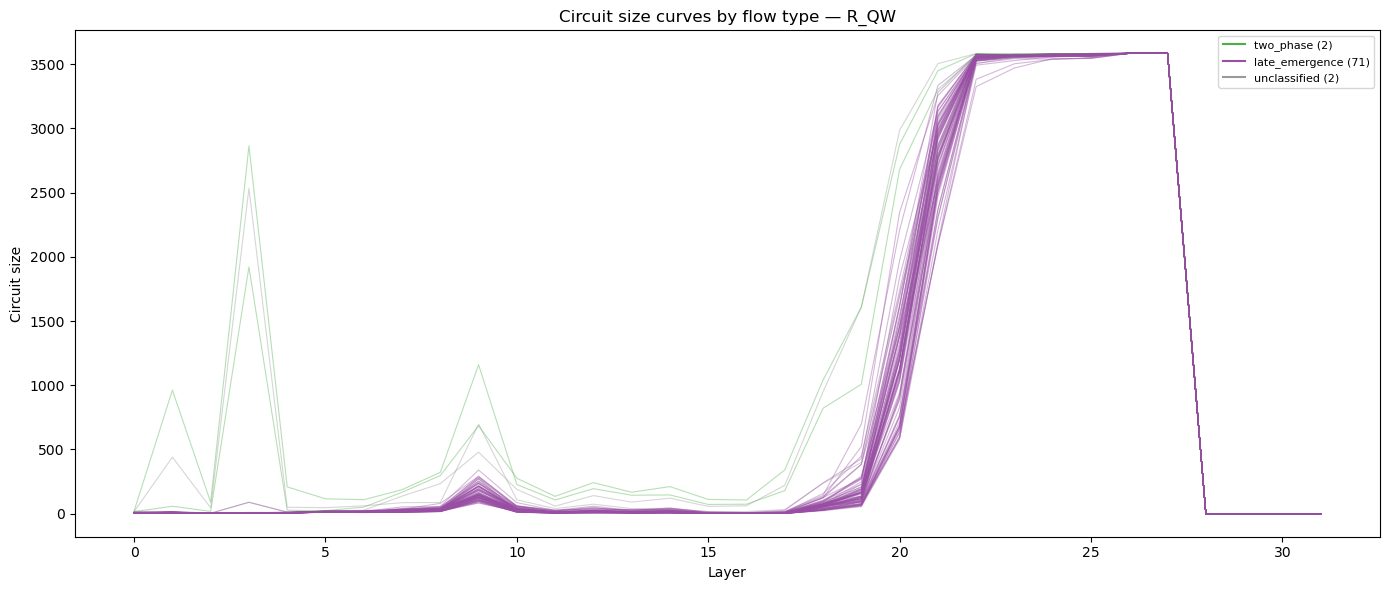

In [5]:
# Cell 5 – Circuit size curves coloured by flow type

FLOW_COLORS = {
    "flash": "#e41a1c", "build_and_hold": "#377eb8",
    "two_phase": "#4daf4a", "late_emergence": "#984ea3",
    "cascade": "#ff7f00", "unclassified": "#999999", "empty": "#cccccc",
}

for (lang, model), sub_ft in df_flow_types.groupby(["lang", "model"]):
    fig, ax = plt.subplots(figsize=(14, 6))
    sub_sizes = df_sizes[(df_sizes["lang"] == lang) & (df_sizes["model"] == model)]

    for _, row in sub_ft.iterrows():
        concept = row["concept"]
        ft = row["flow_type"]
        csub = sub_sizes[sub_sizes["concept"] == concept].sort_values("layer")
        color = FLOW_COLORS.get(ft, "#999999")
        ax.plot(csub["layer"], csub["circuit_size"], color=color, alpha=0.4, linewidth=0.8)

    # Legend
    for ft, color in FLOW_COLORS.items():
        count = len(sub_ft[sub_ft["flow_type"] == ft])
        if count > 0:
            ax.plot([], [], color=color, label=f"{ft} ({count})")
    ax.legend(fontsize=8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Circuit size")
    ax.set_title(f"Circuit size curves by flow type — {lang}_{model}")
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, f"7_E6_size_curves_{lang}_{model}.png"), dpi=150)
    plt.show()

In [6]:
# Cell 6 – Cross-language flow type comparison

# Map equivalent concepts between languages
CROSS_LANG_MAP = {
    "For": ("ast__For", "rust__For"),
    "While": ("ast__While", "rust__While"),
    "If": ("ast__If", "rust__If"),
    "Break": ("ast__Break", "rust__Break"),
    "Continue": ("ast__Continue", "rust__Continue"),
    "Return": ("ast__Return", "rust__Return"),
    "FnDef": ("ast__FunctionDef", "rust__Fn"),
    "Import/Use": ("ast__Import", "rust__Use"),
}

cross_rows = []
for abstract, (py_concept, rs_concept) in CROSS_LANG_MAP.items():
    for model in ["QW"]:
        py_ft = df_flow_types[(df_flow_types["lang"] == "P") & (df_flow_types["model"] == model) &
                              (df_flow_types["concept"] == py_concept)]
        rs_ft = df_flow_types[(df_flow_types["lang"] == "R") & (df_flow_types["model"] == model) &
                              (df_flow_types["concept"] == rs_concept)]
        if len(py_ft) > 0 and len(rs_ft) > 0:
            cross_rows.append({
                "abstract_concept": abstract,
                "model": model,
                "python_flow": py_ft.iloc[0]["flow_type"],
                "rust_flow": rs_ft.iloc[0]["flow_type"],
                "match": py_ft.iloc[0]["flow_type"] == rs_ft.iloc[0]["flow_type"],
            })

df_cross = pd.DataFrame(cross_rows)
if len(df_cross) > 0:
    print("Cross-language flow type comparison:")
    display(df_cross)
    agreement = df_cross["match"].mean()
    print(f"\nAgreement: {agreement:.0%}")
else:
    print("Insufficient data for cross-language comparison.")

Cross-language flow type comparison:


,abstract_concept,model,python_flow,rust_flow,match
0,For,QW,late_emergence,late_emergence,True
1,While,QW,late_emergence,late_emergence,True
2,If,QW,late_emergence,late_emergence,True
3,Break,QW,two_phase,late_emergence,False
4,Continue,QW,two_phase,late_emergence,False
5,Return,QW,late_emergence,late_emergence,True
6,FnDef,QW,late_emergence,late_emergence,True
7,Import/Use,QW,two_phase,two_phase,True



Agreement: 75%


In [7]:
# Cell 7 – Save

df_flow.to_csv(os.path.join(DATA_DIR, "7_E6_flow_vectors.csv"), index=False)
df_sizes.to_csv(os.path.join(DATA_DIR, "7_E6_circuit_sizes.csv"), index=False)
df_flow_types.to_csv(os.path.join(DATA_DIR, "7_E6_flow_type_assignments.csv"), index=False)
print(f"Saved to {DATA_DIR}")

print("\n10 complete.")

Saved to /Users/piotrwilam/Data/New-Atlas

10 complete.
